In the whole exercise, we will work with the "mpg" dataset from seaborn dataset. Start by loading dataset "mpg" from the load_dataset method in seaborn module. The goal will be to use linear regression to predict mpg - miles per gallon.

In [208]:
import seaborn as sns


mpg_df = sns.load_dataset('mpg')


a) Start by doing some initial EDA such as info(), describe() and figure out what you want to do with the missing values.

In [209]:
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [210]:
mpg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [211]:
mpg_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [212]:
mpg_df = mpg_df.drop(columns=['origin', 'name']) # .drop(columns=['origin', 'name']) är tydligare än .drop(['origin', 'name'], axis=1)
mpg_df = mpg_df.dropna()

In [213]:
mpg_df["liter_per_100km"] = 1 / (0.00425144 * mpg_df["mpg"])  # km per liter -> liter per 100 km
mpg_df = mpg_df.drop(columns=['mpg']) # .drop(columns=['origin', 'name']) är tydligare än .drop(['origin', 'name'], axis=1)

mpg_df.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,liter_per_100km
0,8,307.0,130.0,3504,12.0,70,13.067468
1,8,350.0,165.0,3693,11.5,70,15.680961
2,8,318.0,150.0,3436,11.0,70,13.067468
3,8,304.0,150.0,3433,12.0,70,14.700901
4,8,302.0,140.0,3449,10.5,70,13.836142


array([[<Axes: title={'center': 'cylinders'}>,
        <Axes: title={'center': 'displacement'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'acceleration'}>,
        <Axes: title={'center': 'model_year'}>],
       [<Axes: title={'center': 'liter_per_100km'}>, <Axes: >, <Axes: >]],
      dtype=object)

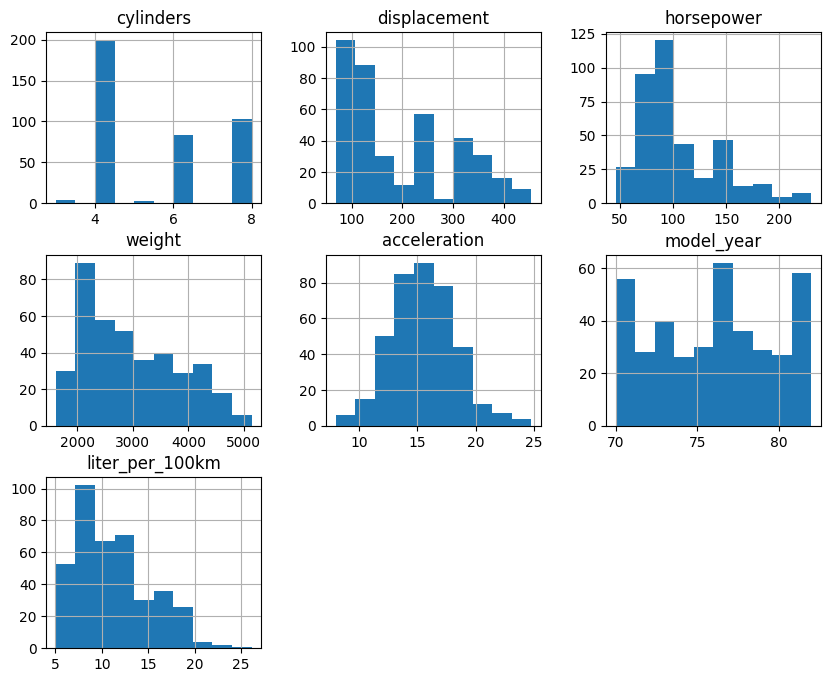

In [214]:
mpg_df.hist(figsize=(10,8))


<Axes: xlabel='weight', ylabel='liter_per_100km'>

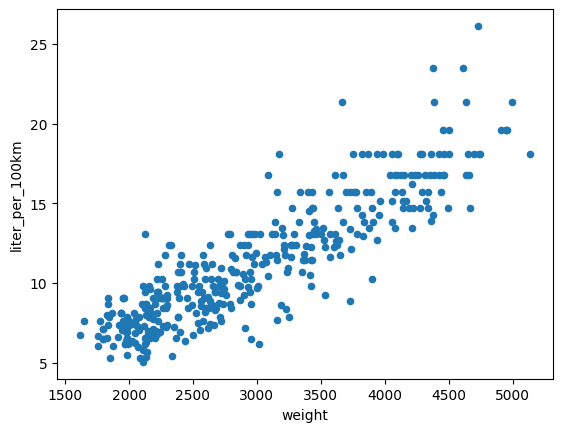

In [215]:
import matplotlib.pyplot as plt # MÅSTE BORT
mpg_df.plot.scatter(x='weight', y='liter_per_100km')

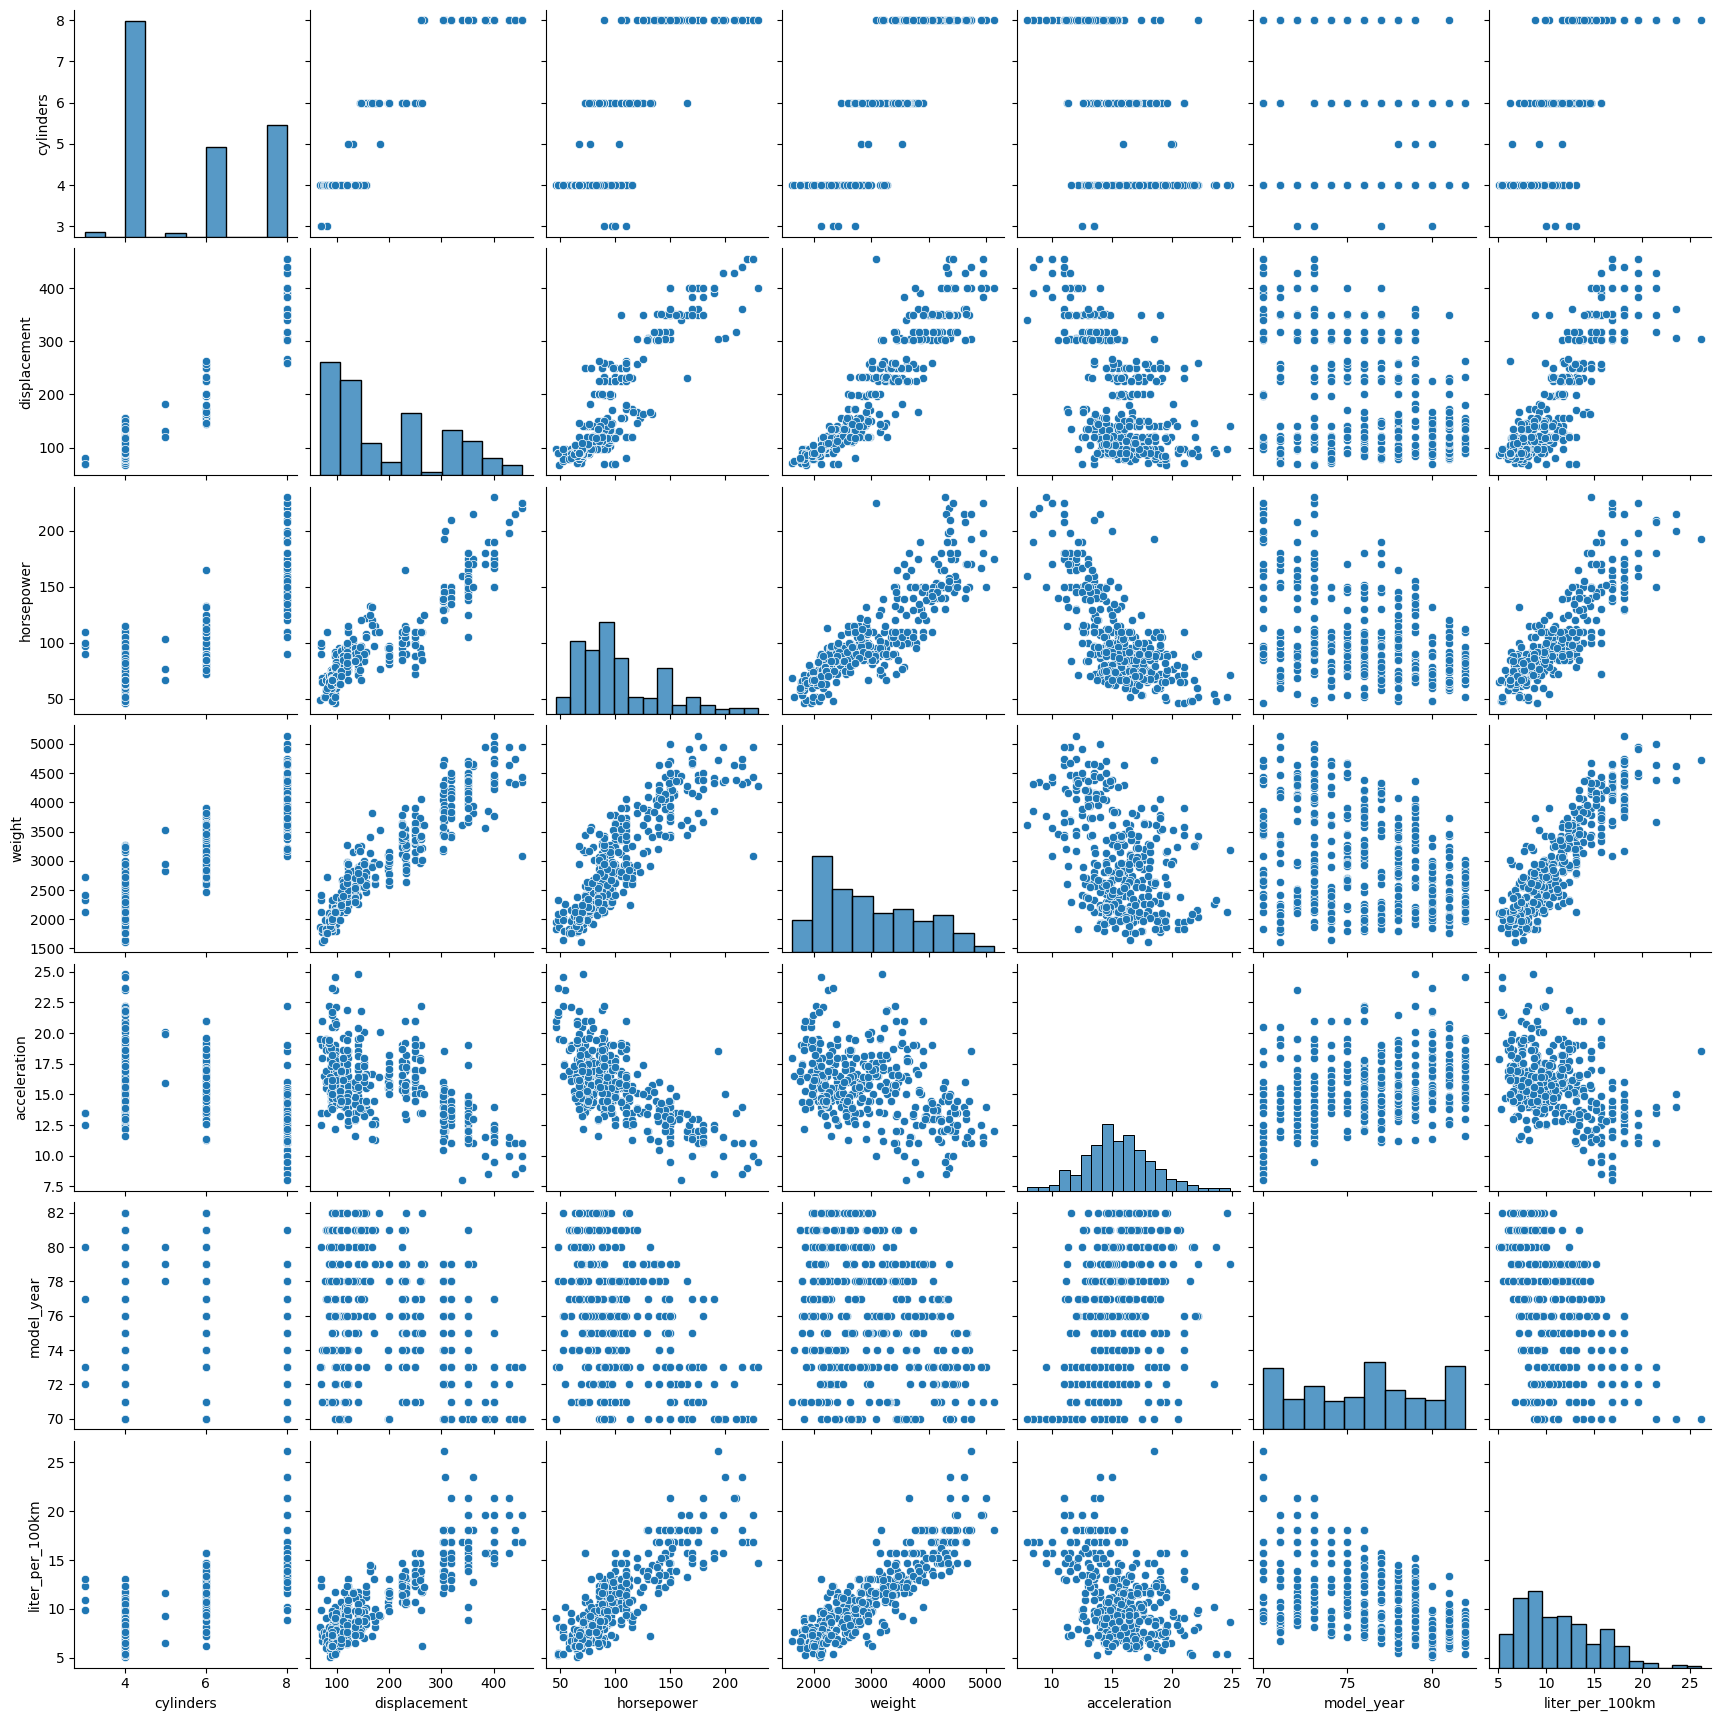

In [216]:
sns.pairplot(mpg_df)


In [217]:
from sklearn.model_selection import train_test_split

X = mpg_df.drop(columns=["liter_per_100km"])
y = mpg_df["liter_per_100km"]
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(392,)


In [218]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)


In [219]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
print("RMSE", root_mean_squared_error(y_test, y_pred))


MSE: 1.453132782770322
R2: 0.8975201530335067
RMSE 1.205459573262547


In [220]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

models = {
    "Linear regression (SVD)": LinearRegression(),

    "Linear regression (SVD) scaled": Pipeline([
        ("scaler", StandardScaler()),
        ("linreg", LinearRegression())
    ]),

    "Polynomial degree 1": Pipeline([
        ("poly", PolynomialFeatures(degree=1, include_bias=False)),
        ("linreg", LinearRegression())
    ]),

    "Polynomial degree 2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linreg", LinearRegression())
    ]),

    "Polynomial degree 3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("linreg", LinearRegression())
    ])
}

In [221]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5

    results.append({
        "model": name,
        "mae": mae,
        "mse": mse,
        "rmse": rmse
    })


In [222]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values("rmse")

comparison_df

,model,mae,mse,rmse
4,Polynomial degree 3,0.868982,1.327805,1.152304
1,Linear regression (SVD) scaled,0.933435,1.453133,1.205460
2,Polynomial degree 1,0.933435,1.453133,1.205460
0,Linear regression (SVD),0.933435,1.453133,1.205460
3,Polynomial degree 2,0.885667,1.454895,1.206190


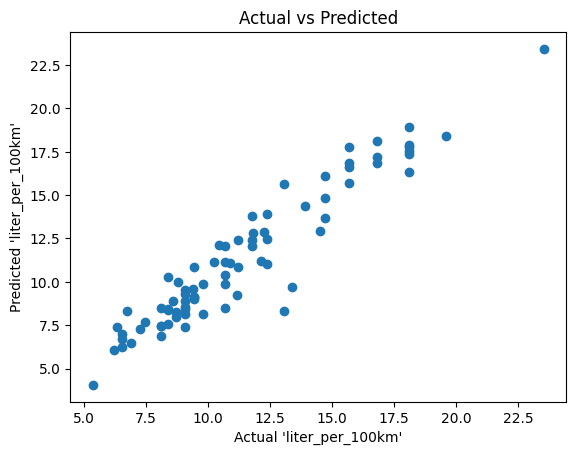

In [223]:
best_model = models["Polynomial degree 2"]

y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual 'liter_per_100km'")
plt.ylabel("Predicted 'liter_per_100km'")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
lin_model.coef_

array([ 0.33997916, -0.00260698,  0.02528097,  0.00247984,  0.07562817,
       -0.31401465])

In [225]:
lin_model.intercept_

np.float64(22.561639581623332)

In [226]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lin_model.coef_
})

coef_df.sort_values("coefficient", key=abs, ascending=False)

,feature,coefficient
0,cylinders,0.339979
5,model_year,-0.314015
4,acceleration,0.075628
2,horsepower,0.025281
1,displacement,-0.002607
3,weight,0.002480


In [ ]:
mpg_df.corr(numeric_only=True)["liter_per_100km"].sort_values(ascending=False)

KeyError: 'liter_per_100km'